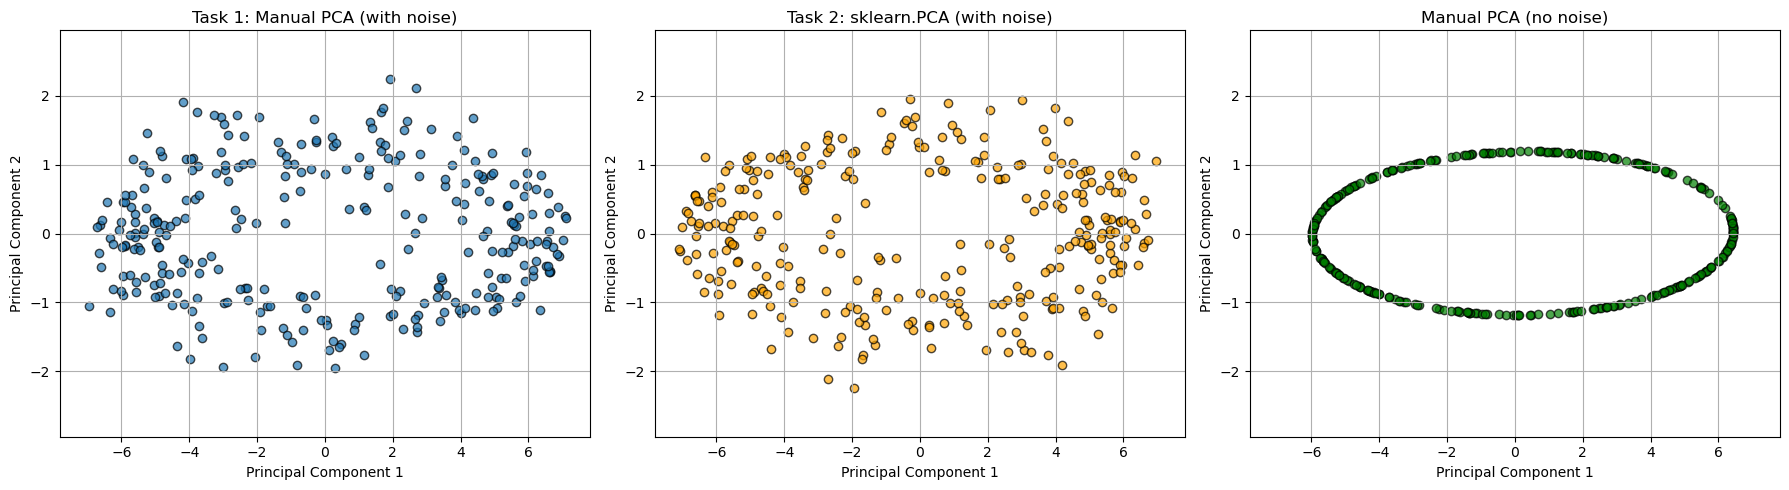

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------------------
# データ準備（課題1）
# -------------------
np.random.seed(42)

# 2次元の楕円状データを生成 (サンプル数m=300)
m = 300
theta = np.random.uniform(0, 2 * np.pi, m)
a, b = 2, 1  # 楕円の半径
X_2d = np.column_stack((a * np.cos(theta), b * np.sin(theta)))

# ランダムな回転行列（2x5）を作成し、5次元にリフト + ノイズ付加
W = np.random.randn(2, 5)
X_5d = X_2d @ W + np.random.randn(m, 5) * 0.5

# ノイズなしのデータも準備
X_5d_no_noise = X_2d @ W

# -------------------
# スクラッチ実装（課題1） - ノイズあり
# -------------------
# 1. 中心化して共分散行列を計算 (sklearnと同じスケールで)
X_centered = X_5d - np.mean(X_5d, axis=0)
cov_mat = (X_centered.T @ X_centered) / (m - 1)

# 2. np.linalg.eigh で固有値分解
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

# ※ eighは固有値が「昇順（小さい順）」で出力されるため、降順（大きい順）に並べ替える
idx = np.argsort(eigenvalues)[::-1]
eigenvectors_sorted = eigenvectors[:, idx]

# 3. 上位2つの固有ベクトルを取得し、データを射影
top2_eigenvectors = eigenvectors_sorted[:, :2]
X_pca_manual = X_centered @ top2_eigenvectors

# -------------------
# スクラッチ実装（課題1） - ノイズなし
# -------------------
X_centered_no_noise = X_5d_no_noise - np.mean(X_5d_no_noise, axis=0)
cov_mat_no_noise = (X_centered_no_noise.T @ X_centered_no_noise) / (m - 1)
eigenvalues_no, eigenvectors_no = np.linalg.eigh(cov_mat_no_noise)
idx_no = np.argsort(eigenvalues_no)[::-1]
eigenvectors_sorted_no = eigenvectors_no[:, idx_no]
top2_eigenvectors_no = eigenvectors_sorted_no[:, :2]
X_pca_manual_no_noise = X_centered_no_noise @ top2_eigenvectors_no

# -------------------
# sklearnとの比較（課題2）
# -------------------
pca = PCA(n_components=2)
# sklearnのPCAは内部で自動的に中心化を行ってくれます
X_pca_sklearn = pca.fit_transform(X_5d)

# -------------------
# プロットによる確認
# -------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 軸の範囲を揃えるために共通の範囲を計算
all_x = np.concatenate([X_pca_manual[:, 0], X_pca_sklearn[:, 0], X_pca_manual_no_noise[:, 0]])
all_y = np.concatenate([X_pca_manual[:, 1], X_pca_sklearn[:, 1], X_pca_manual_no_noise[:, 1]])
x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()
margin = 0.05 * max(x_max - x_min, y_max - y_min)  # 5%余裕

# 手動PCAのプロット (ノイズあり)
axes[0].scatter(X_pca_manual[:, 0], X_pca_manual[:, 1], alpha=0.7, edgecolor='k')
axes[0].set_title("Task 1: Manual PCA (with noise)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_xlim(x_min - margin, x_max + margin)
axes[0].set_ylim(y_min - margin, y_max + margin)
axes[0].grid(True)

# sklearn PCAのプロット (ノイズあり)
axes[1].scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], alpha=0.7, edgecolor='k', color='orange')
axes[1].set_title("Task 2: sklearn.PCA (with noise)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].set_xlim(x_min - margin, x_max + margin)
axes[1].set_ylim(y_min - margin, y_max + margin)
axes[1].grid(True)

# 手動PCAのプロット (ノイズなし)
axes[2].scatter(X_pca_manual_no_noise[:, 0], X_pca_manual_no_noise[:, 1], alpha=0.7, edgecolor='k', color='green')
axes[2].set_title("Manual PCA (no noise)")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")
axes[2].set_xlim(x_min - margin, x_max + margin)
axes[2].set_ylim(y_min - margin, y_max + margin)
axes[2].grid(True)

plt.tight_layout()
plt.show()